# Extension: Monte Carlo Value-at-Risk for NVIDIA

*Individual extension by Aylin Yasgul, building on the group project in `nvidia_volatility_risk.ipynb`.*

The main notebook estimates Value-at-Risk (VaR) and Expected Shortfall (ES) three ways: historical, normal and Student-t.
This notebook adds a fourth method, **Monte Carlo simulation**, using the same AR(1)-GARCH(1,1) model with Student-t errors.

Two questions:
1. What is NVIDIA's 1-day 99% VaR and ES going into 2025, given the volatility at the end of 2024?
2. Over a **10-day** horizon (the regulatory standard for market risk), does the common square-root-of-time shortcut give the right answer?

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yfinance as yf
from arch import arch_model

# Same data as the main notebook: daily NVDA log returns in %, 2014-2024
px = yf.download("NVDA", start="2014-01-01", end="2025-01-01", progress=False, auto_adjust=True)
close = px["Close"].squeeze()
returns = (np.log(close / close.shift(1)) * 100).dropna()
print(f"{len(returns):,} daily returns, {returns.index[0].date()} to {returns.index[-1].date()}")

2,767 daily returns, 2014-01-03 to 2024-12-31


In [2]:
# Same model as the main notebook: AR(1) mean, GARCH(1,1) volatility, Student-t errors
garch_fit = arch_model(returns, mean="AR", lags=1, vol="Garch", p=1, q=1, dist="t").fit(disp="off")
p = garch_fit.params
long_run_vol = np.sqrt(p["omega"] / (1 - p["alpha[1]"] - p["beta[1]"]))
print(p.round(4))
print(f"\nVolatility on the last day of 2024: {garch_fit.conditional_volatility.iloc[-1]:.2f}% a day")
print(f"Long-run volatility implied by the model: {long_run_vol:.2f}% a day")

Const       0.2239
NVDA[1]    -0.0299
omega       0.1039
alpha[1]    0.0637
beta[1]     0.9290
nu          4.1179
Name: params, dtype: float64

Volatility on the last day of 2024: 2.35% a day
Long-run volatility implied by the model: 3.77% a day


## How Monte Carlo VaR works

Instead of using a formula, we let the fitted model generate many possible futures:

1. Start from the last day of data (end of 2024), with the model's current volatility.
2. Draw a random Student-t shock for each day, update the volatility with the GARCH equation, and repeat for 10 days.
3. Do this **50,000 times**, giving 50,000 possible 1-day and 10-day returns.
4. The **99% VaR** is the 1st percentile of those outcomes; the **99% ES** is the average of the outcomes beyond it.

Because each path updates volatility day by day, the simulation captures both fat tails and changing volatility, which a single formula cannot do over several days.

In [3]:
N_SIMS, HORIZON = 50_000, 10
fc = garch_fit.forecast(horizon=HORIZON, method="simulation", simulations=N_SIMS,
                        reindex=False, random_state=np.random.RandomState(42))
paths = fc.simulations.values[-1]          # shape: (simulations, days)
one_day, ten_day = paths[:, 0], paths.sum(axis=1)

def var_es(x, level):
    var = np.percentile(x, 100 * (1 - level))
    return var, x[x <= var].mean()

rows = []
for name, x in [("1-day", one_day), ("10-day", ten_day)]:
    for level in (0.95, 0.99):
        v, e = var_es(x, level)
        rows.append({"Horizon": name, "Confidence": f"{level:.0%}", "VaR (%)": round(v, 2), "ES (%)": round(e, 2)})
results = pd.DataFrame(rows)
results

,Horizon,Confidence,VaR (%),ES (%)
0,1-day,95%,-3.32,-5.07
1,1-day,99%,-5.92,-8.37
2,10-day,95%,-9.40,-13.94
3,10-day,99%,-16.55,-22.00


## Does the square-root-of-time rule hold?

A common shortcut scales 1-day VaR to 10 days by multiplying by $\sqrt{10}$. That assumes returns are independent and normally distributed.
The simulation gives the 10-day number directly, so we can check the shortcut.

In [4]:
var1, _ = var_es(one_day, 0.99)
var10, es10 = var_es(ten_day, 0.99)
sqrt_rule = var1 * np.sqrt(10)
gap = (sqrt_rule / var10 - 1) * 100
print(f"Monte Carlo 10-day 99% VaR:         {var10:.2f}%")
print(f"Square-root-of-time 10-day 99% VaR: {sqrt_rule:.2f}%")
print(f"The shortcut overstates 10-day risk by about {gap:.0f}%")

Monte Carlo 10-day 99% VaR:         -16.55%
Square-root-of-time 10-day 99% VaR: -18.72%
The shortcut overstates 10-day risk by about 13%


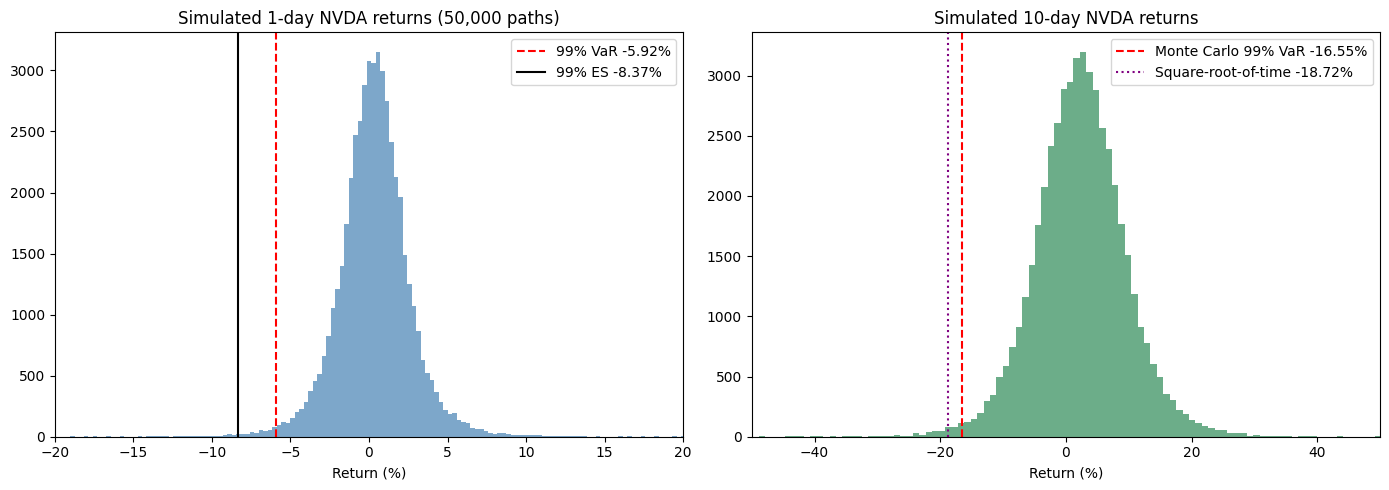

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
v1, e1 = var_es(one_day, 0.99)
axes[0].hist(one_day, bins=200, color="steelblue", alpha=0.7)
axes[0].axvline(v1, color="red", ls="--", label=f"99% VaR {v1:.2f}%")
axes[0].axvline(e1, color="black", label=f"99% ES {e1:.2f}%")
axes[0].set(title="Simulated 1-day NVDA returns (50,000 paths)", xlabel="Return (%)", xlim=(-20, 20)); axes[0].legend()
axes[1].hist(ten_day, bins=200, color="seagreen", alpha=0.7)
axes[1].axvline(var10, color="red", ls="--", label=f"Monte Carlo 99% VaR {var10:.2f}%")
axes[1].axvline(sqrt_rule, color="purple", ls=":", label=f"Square-root-of-time {sqrt_rule:.2f}%")
axes[1].set(title="Simulated 10-day NVDA returns", xlabel="Return (%)", xlim=(-50, 50)); axes[1].legend()
plt.tight_layout(); plt.savefig("figures/13_monte_carlo_var.png", dpi=150); plt.show()

## Findings

- **Going into 2025, NVIDIA was calmer than its long-run average**, so the forward-looking 1-day 99% VaR from the simulation is smaller than the full-sample estimates in the main notebook. This is the point of conditional risk: the number moves with the market.
- **The square-root-of-time rule overstates 10-day risk** for NVIDIA. Fat-tailed daily shocks partly average out over several days, so 10-day losses are less extreme than scaling the 1-day number suggests.
- **Monte Carlo gives the multi-day answer directly** from the same model, without the independence and normality assumptions behind the shortcut.

*Limits:* results depend on the GARCH(1,1)-t model being a reasonable description of NVIDIA, and the simulation is not back-tested against later data.